In [11]:
%pip install pandas

import pandas as pd
armas1 = pd.read_csv(r'armas1_processed.csv')
armas2 = pd.read_csv(r'armas2_processed.csv')
armas3 = pd.read_csv(r'armas3_processed.csv')


Note: you may need to restart the kernel to use updated packages.


# import libraries

In [12]:
!pip install scikit-learn
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline       
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

# Copy your train,validation and test sets

In [13]:
train_df = armas1.copy()
valid_df = armas2.copy()    
test_df  = armas3.copy()

# Define the target and columns to remove

In [14]:
TARGET = 'Index_K'

DROP_COLS = [TARGET, 'NAIRASV3', 'NAIRASV2', 'Datetime', 'Vehicle_ID', 'ARMAS']

# Separate input features X and output y

In [15]:
def split_xy(df):
    X = df.drop(columns=DROP_COLS, errors='ignore')
    y = df[TARGET]
    return X, y
X_train, y_train = split_xy(train_df)
X_valid, y_valid = split_xy(valid_df)
X_test, y_test   = split_xy(test_df)

In [16]:
print("Train shape:", X_train.shape)
print("Valid shape:", X_valid.shape)
print("Test shape :", X_test.shape)

print("\nTrain class counts:")
print(y_train.value_counts().sort_index())

Train shape: (32380, 43)
Valid shape: (30787, 43)
Test shape : (29309, 43)

Train class counts:
Index_K
0     8871
1    18185
2     5324
Name: count, dtype: int64


Detect the numeric and categorical columns

In [17]:
numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=['number']).columns.tolist()

print("\nNumeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


Numeric columns: ['Latitude', 'Longitude', 'Altitude(Bar)', 'Altitude(GPS)', 'Geomagnetic_latitude', 'Geomagnetic_longitude', 'Geomagnetic_Rc', 'Geomagnetic_Lshell', 'NM_NEWK', 'NM_OULU', 'NM_THUL', 'NM_SOPO', 'SXR_short', 'SXR_long', 'Particles_P1', 'Particles_P5', 'Particles_P10', 'Particles_P30', 'Particles_P50', 'Particles_P100', 'Particles_E20', 'SW_B', 'SW_Bx', 'SW_By', 'SW_Bz', 'SW_V', 'SW_Vx', 'SW_Vy', 'SW_Vz', 'SW_density', 'SW_temperature', 'SW_pressure', 'Index_Kp', 'Index_Dst', 'Index_Ap', 'Solar_sunspots', 'Solar_f107', 'Solar_NPF', 'Solar_SPF', 'Solar_APF', 'Solar_NPF20', 'Solar_SPF20', 'Solar_APF20']
Categorical columns: []


Build preprocessing pipeline

In [18]:
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
])

Manual Tuining of logistic regression

In [19]:
datasets = {
    "armas1": armas1,
    "armas2": armas2,
    "armas3": armas3
}

In [20]:
rotations = [
    ("armas1", "armas2", "armas3"),
    ("armas1", "armas3", "armas2"),
    ("armas2", "armas1", "armas3"),
    ("armas2", "armas3", "armas1"),
    ("armas3", "armas1", "armas2"),
    ("armas3", "armas2", "armas1")
]

In [21]:
#------------------------------------k neighbors-classifier with tuning---------

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.inspection import permutation_importance

# Preprocess the training and validation data
X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)
X_test_processed = preprocessor.transform(X_test)

print("="*70)
print("KNN CLASSIFIER - OPTIMIZED WITH n_neighbors=12")
print("="*70)

# ===== STEP 1: Feature Selection using Permutation Importance =====
print("\n1. FEATURE IMPORTANCE ANALYSIS")
print("-" * 70)

# Train a baseline model for importance analysis
baseline_knn = KNeighborsClassifier(n_neighbors=12, weights='distance', metric='euclidean')
baseline_knn.fit(X_train_processed, y_train)

# Calculate permutation importance
perm_importance = permutation_importance(baseline_knn, X_valid_processed, y_valid, n_repeats=10, random_state=42)
feature_importance_df = pd.DataFrame({
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std,
    'feature': preprocessor.get_feature_names_out()
}).sort_values('importance', ascending=False)

print(f"Top 10 Important Features:")
print(feature_importance_df.head(10))

# Keep features with positive importance (threshold > 0)
important_features = feature_importance_df[feature_importance_df['importance'] > 0].index.tolist()
print(f"\nNumber of important features: {len(important_features)} out of {X_train_processed.shape[1]}")

X_train_selected = X_train_processed[:, important_features]
X_valid_selected = X_valid_processed[:, important_features]
X_test_selected = X_test_processed[:, important_features]

# ===== STEP 2: Compare Different Metrics and Parameters =====
print("\n2. HYPERPARAMETER TUNING - Comparing Different Metrics")
print("-" * 70)

metrics_to_test = ['euclidean', 'manhattan', 'minkowski']
results = []

for metric in metrics_to_test:
    knn = KNeighborsClassifier(n_neighbors=12, weights='distance', metric=metric)
    
    # Cross-validation on selected features
    cv_scores = cross_val_score(knn, X_train_selected, y_train, cv=5, scoring='accuracy')
    
    # Train and evaluate on validation set
    knn.fit(X_train_selected, y_train)
    y_pred_valid = knn.predict(X_valid_selected)
    valid_acc = accuracy_score(y_valid, y_pred_valid)
    
    results.append({
        'Metric': metric,
        'CV Accuracy': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Validation Accuracy': valid_acc
    })
    
    print(f"\n{metric.upper()}:")
    print(f"  Cross-Validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"  Validation Accuracy:       {valid_acc:.4f}")

# ===== STEP 3: Select Best Model and Test on Test Set =====
best_result = max(results, key=lambda x: x['Validation Accuracy'])
best_metric = best_result['Metric']

print("\n3. FINAL MODEL EVALUATION")
print("-" * 70)
print(f"Best Metric: {best_metric.upper()}")
print(f"Best Validation Accuracy: {best_result['Validation Accuracy']:.4f}")

# Train final model with best metric
final_knn = KNeighborsClassifier(n_neighbors=12, weights='distance', metric=best_metric)
final_knn.fit(X_train_selected, y_train)

# Validation set evaluation
y_pred_valid_final = final_knn.predict(X_valid_selected)
print(f"\nValidation Set Results:")
print(f"Accuracy: {accuracy_score(y_valid, y_pred_valid_final):.4f}")
print(f"\nClassification Report (Validation):")
print(classification_report(y_valid, y_pred_valid_final))

# Test set evaluation
y_pred_test = final_knn.predict(X_test_selected)
print(f"\nTest Set Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(f"\nClassification Report (Test):")
print(classification_report(y_test, y_pred_test))

# Sample prediction
sample = X_train.iloc[[0]]
sample_processed = preprocessor.transform(sample)
sample_selected = sample_processed[:, important_features]
print(f"\nSample Prediction (first training sample):")
print(f"Prediction: {final_knn.predict(sample_selected)}")
print(f"Probability: {final_knn.predict_proba(sample_selected)}")

KNN CLASSIFIER - OPTIMIZED WITH n_neighbors=12

1. FEATURE IMPORTANCE ANALYSIS
----------------------------------------------------------------------
Top 10 Important Features:
    importance       std                    feature
6     0.060672  0.002462        num__Geomagnetic_Rc
3     0.016322  0.001258         num__Altitude(GPS)
4     0.011355  0.000738  num__Geomagnetic_latitude
0     0.010482  0.000776              num__Latitude
38    0.009452  0.000797             num__Solar_SPF
26    0.008101  0.001621                 num__SW_Vx
25    0.008049  0.001688                  num__SW_V
33    0.006740  0.001017             num__Index_Dst
2     0.006529  0.001248         num__Altitude(Bar)
40    0.006525  0.000881           num__Solar_NPF20

Number of important features: 35 out of 43

2. HYPERPARAMETER TUNING - Comparing Different Metrics
----------------------------------------------------------------------

EUCLIDEAN:
  Cross-Validation Accuracy: 0.3624 (+/- 0.1062)
  Validation Accura

In [22]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import permutations

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.neighbors import KNeighborsClassifier as KNNClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc
)
models = {
     "KNN": KNNClassifier(n_neighbors=12, weights='distance', metric='manhattan')


}
# ============================================================
# 3. CONFIGURATION
# ============================================================
TARGET = "Index_K"
CLASS_LABELS = [0, 1, 2]
CLASS_NAMES = ["Background", "Moderate", "Elevated"]

# remove leakage columns / metadata / measured and physics outputs
DROP_COLS = [
    TARGET,
    "NAIRASV2",
    "NAIRASV3",
    "Datetime",
    "Vehicle_ID",
    "ARMAS"
]

# ============================================================
# 4. SPLIT X AND y
# ============================================================
def split_xy(df):
    X = df.drop(columns=DROP_COLS, errors="ignore").copy()
    y = df[TARGET].copy()
    return X, y
# ============================================================
# 5. DATA CLEANING
# ============================================================
def clean_features(df):
    df = df.copy()

    # replace inf with nan
    df = df.replace([np.inf, -np.inf], np.nan)

    # try converting object columns to numeric if possible
    for col in df.columns:
        if df[col].dtype == "object":
            converted = pd.to_numeric(df[col], errors="ignore")
            df[col] = converted

    return df

def clean_target(y):
    y = pd.to_numeric(y, errors="coerce")
    valid_mask = y.isin(CLASS_LABELS)
    return y[valid_mask].astype(int), valid_mask
# ============================================================
# 8. PHYSICS-BASED BASELINE USING NAIRASV3
# ============================================================
def physics_baseline_predict(df, nairas_col="NAIRASV3"):
    if nairas_col not in df.columns:
        raise ValueError(f"Column '{nairas_col}' not found in dataframe.")

    values = pd.to_numeric(df[nairas_col], errors="coerce")

    pred = np.select(
        [
            values < 5,
            (values >= 5) & (values < 15),
            (values >= 15) & (values < 45)
        ],
        [0, 1, 2],
        default=np.nan
    )

    return pd.Series(pred, index=df.index)
# ============================================================
# 9. METRIC FUNCTION
# ============================================================
def evaluate_multiclass(y_true, y_pred, y_proba=None):
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0)
    }

    if y_proba is not None:
        try:
            y_true_bin = label_binarize(y_true, classes=CLASS_LABELS)
            results["roc_auc_ovr_macro"] = roc_auc_score(
                y_true_bin,
                y_proba,
                multi_class="ovr",
                average="macro"
            )
        except Exception:
            results["roc_auc_ovr_macro"] = np.nan
    else:
        results["roc_auc_ovr_macro"] = np.nan

    return results

# ============================================================
# 10. DEFINE ROTATIONS
# ============================================================
rotations = list(permutations(datasets.keys(), 3))

all_results = []
all_conf_matrices = []
failed_runs = []

# store trained pipelines for possible later use
trained_models_for_interpretation = {}

# ============================================================
# 11. MAIN LOOP FOR ML MODELS
# ============================================================
for model_name, estimator in models.items():

    print("\n" + "=" * 100)
    print(f"MODEL: {model_name}")
    print("=" * 100)

    for train_name, valid_name, test_name in rotations:

        print(f"\nRotation: Train={train_name}, Validation={valid_name}, Test={test_name}")

        train_df = datasets[train_name].copy()
        valid_df = datasets[valid_name].copy()
        test_df = datasets[test_name].copy()

        # split
        X_train, y_train = split_xy(train_df)
        X_valid, y_valid = split_xy(valid_df)
        X_test, y_test = split_xy(test_df)

        # clean features
        X_train = clean_features(X_train)
        X_valid = clean_features(X_valid)
        X_test = clean_features(X_test)

        # clean targets
        y_train, mask_train = clean_target(y_train)
        X_train = X_train.loc[mask_train]

        y_valid, mask_valid = clean_target(y_valid)
        X_valid = X_valid.loc[mask_valid]

        y_test, mask_test = clean_target(y_test)
        X_test = X_test.loc[mask_test]

        # combine train + validation
        X_train_final = pd.concat([X_train, X_valid], axis=0)
        y_train_final = pd.concat([y_train, y_valid], axis=0)

        # debug class counts
        print("Train+Valid class counts:")
        print(pd.Series(y_train_final).value_counts().sort_index())

        print("Test class counts:")
        print(pd.Series(y_test).value_counts().sort_index())

        # skip if too few classes
        unique_train_classes = sorted(pd.Series(y_train_final).dropna().unique())
        if len(unique_train_classes) < 2:
            print("Skipping rotation: fewer than 2 classes in training.")
            failed_runs.append({
                "model": model_name,
                "rotation": f"{train_name}-{valid_name}-{test_name}",
                "reason": "fewer than 2 training classes"
            })
            continue

        # pipeline
        model = Pipeline([
            ("prep", preprocessor),
            ("clf", estimator)
        ])

        # fit safely
        try:
            model.fit(X_train_final, y_train_final)
        except Exception as e:
            print("REAL ERROR TYPE:", type(e).__name__)
            print("REAL ERROR MESSAGE:", e)

            failed_runs.append({
                "model": model_name,
                "rotation": f"{train_name}-{valid_name}-{test_name}",
                "reason": f"{type(e).__name__}: {e}"
            })
            continue

        # predict
        try:
            y_test_pred = model.predict(X_test)
        except Exception as e:
            print("Prediction failed:", e)
            failed_runs.append({
                "model": model_name,
                "rotation": f"{train_name}-{valid_name}-{test_name}",
                "reason": f"Prediction failed: {type(e).__name__}: {e}"
            })
            continue

        # predict probabilities if available
        y_test_proba = None
        try:
            if hasattr(model.named_steps["clf"], "predict_proba"):
                y_test_proba = model.predict_proba(X_test)
        except Exception:
            y_test_proba = None

        # metrics
        metrics = evaluate_multiclass(y_test, y_test_pred, y_test_proba)

        result_row = {
            "model": model_name,
            "train_set": train_name,
            "valid_set": valid_name,
            "test_set": test_name,
            **metrics
        }
        all_results.append(result_row)

        cm = confusion_matrix(y_test, y_test_pred, labels=CLASS_LABELS)
        all_conf_matrices.append({
            "model": model_name,
            "rotation": f"{train_name}-{valid_name}-{test_name}",
            "cm": cm
        })

        print(f"Accuracy          : {metrics['accuracy']:.4f}")
        print(f"Precision Macro   : {metrics['precision_macro']:.4f}")
        print(f"Recall Macro      : {metrics['recall_macro']:.4f}")
        print(f"F1 Macro          : {metrics['f1_macro']:.4f}")
        if np.isnan(metrics["roc_auc_ovr_macro"]):
            print("ROC-AUC OVR Macro : N/A")
        else:
            print(f"ROC-AUC OVR Macro : {metrics['roc_auc_ovr_macro']:.4f}")

        # store one trained version for later interpretation
        trained_models_for_interpretation[(model_name, train_name, valid_name, test_name)] = model



MODEL: KNN

Rotation: Train=armas1, Validation=armas2, Test=armas3
Train+Valid class counts:
Index_K
0    18323
1    34529
2    10315
Name: count, dtype: int64
Test class counts:
Index_K
0     8813
1    15538
2     4958
Name: count, dtype: int64
Accuracy          : 0.5712
Precision Macro   : 0.5406
Recall Macro      : 0.5003
F1 Macro          : 0.5129
ROC-AUC OVR Macro : 0.6836

Rotation: Train=armas1, Validation=armas3, Test=armas2
Train+Valid class counts:
Index_K
0    17684
1    33723
2    10282
Name: count, dtype: int64
Test class counts:
Index_K
0     9452
1    16344
2     4991
Name: count, dtype: int64
Accuracy          : 0.6012
Precision Macro   : 0.5536
Recall Macro      : 0.5129
F1 Macro          : 0.5237
ROC-AUC OVR Macro : 0.6974

Rotation: Train=armas2, Validation=armas1, Test=armas3
Train+Valid class counts:
Index_K
0    18323
1    34529
2    10315
Name: count, dtype: int64
Test class counts:
Index_K
0     8813
1    15538
2     4958
Name: count, dtype: int64
Accuracy     


PHYSICS-BASED BASELINE: NAIRASV3

Rotation: Train=armas1, Validation=armas2, Test=armas3
Accuracy        : 0.6176
Precision Macro : 0.6786
Recall Macro    : 0.4958
F1 Macro        : 0.5122

Rotation: Train=armas1, Validation=armas3, Test=armas2
Accuracy        : 0.6429
Precision Macro : 0.7047
Recall Macro    : 0.5265
F1 Macro        : 0.5501

Rotation: Train=armas2, Validation=armas1, Test=armas3
Accuracy        : 0.6176
Precision Macro : 0.6786
Recall Macro    : 0.4958
F1 Macro        : 0.5122

Rotation: Train=armas2, Validation=armas3, Test=armas1
Accuracy        : 0.6467
Precision Macro : 0.6960
Recall Macro    : 0.4865
F1 Macro        : 0.5065

Rotation: Train=armas3, Validation=armas1, Test=armas2
Accuracy        : 0.6429
Precision Macro : 0.7047
Recall Macro    : 0.5265
F1 Macro        : 0.5501

Rotation: Train=armas3, Validation=armas2, Test=armas1
Accuracy        : 0.6467
Precision Macro : 0.6960
Recall Macro    : 0.4865
F1 Macro        : 0.5065

ALL RESULTS
                 

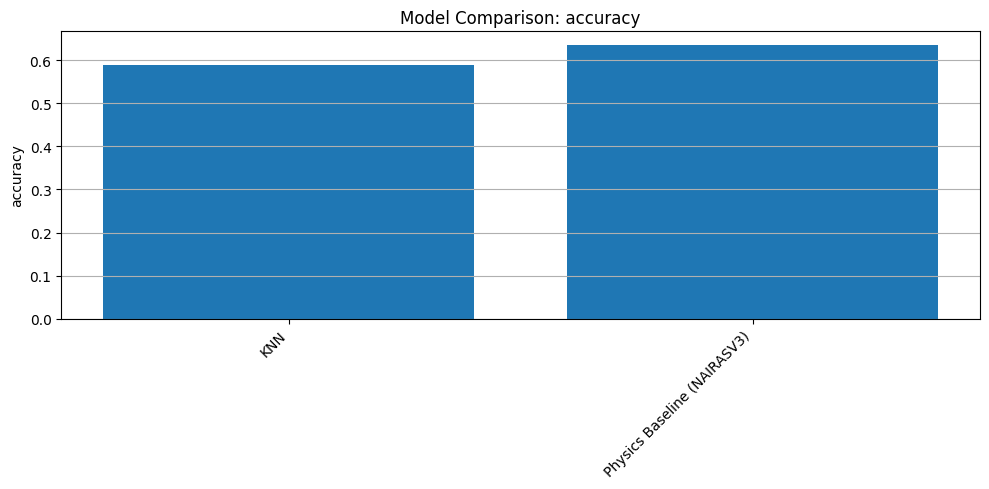

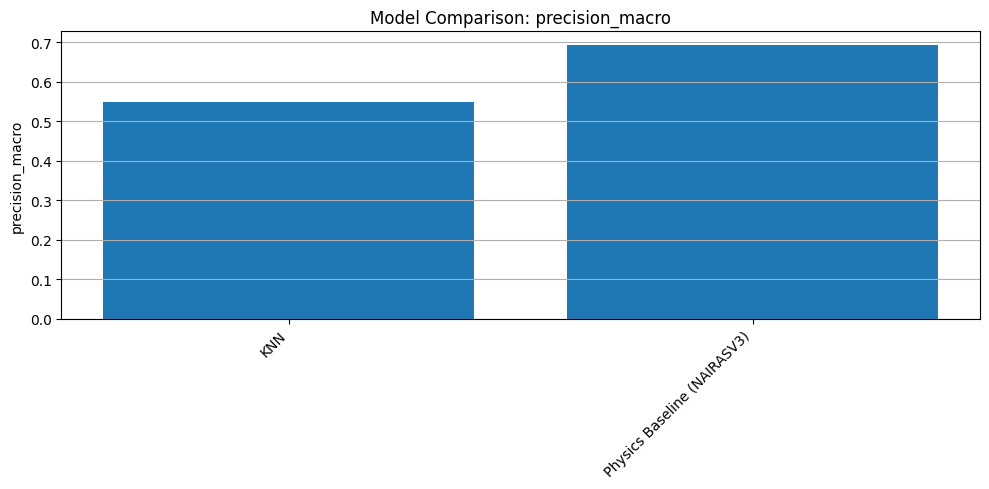

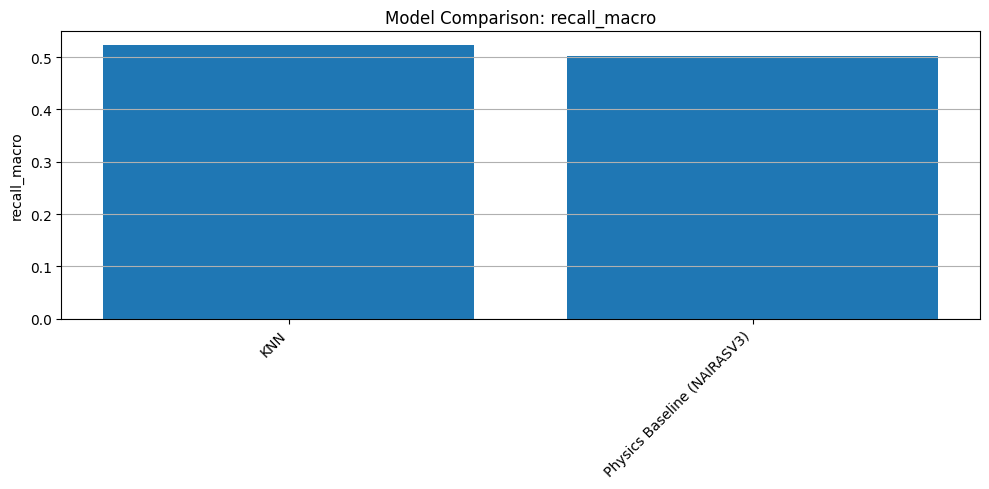

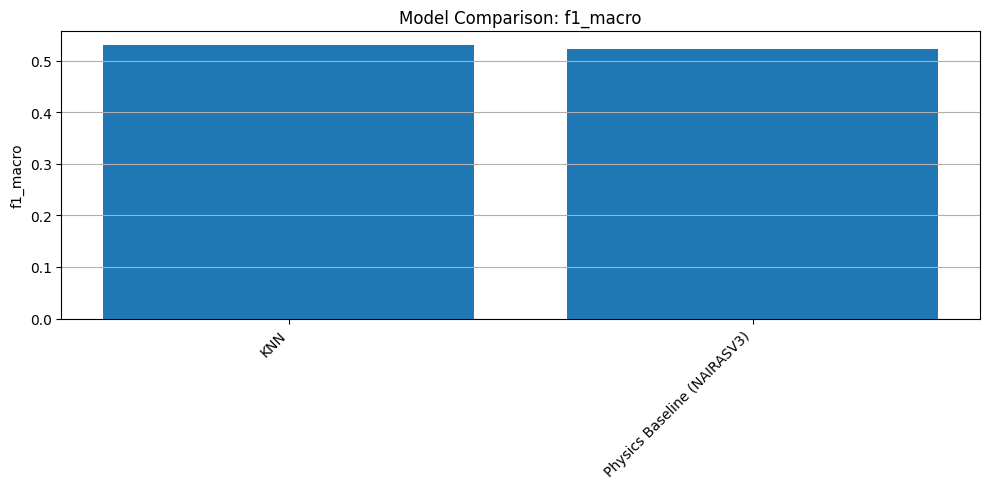

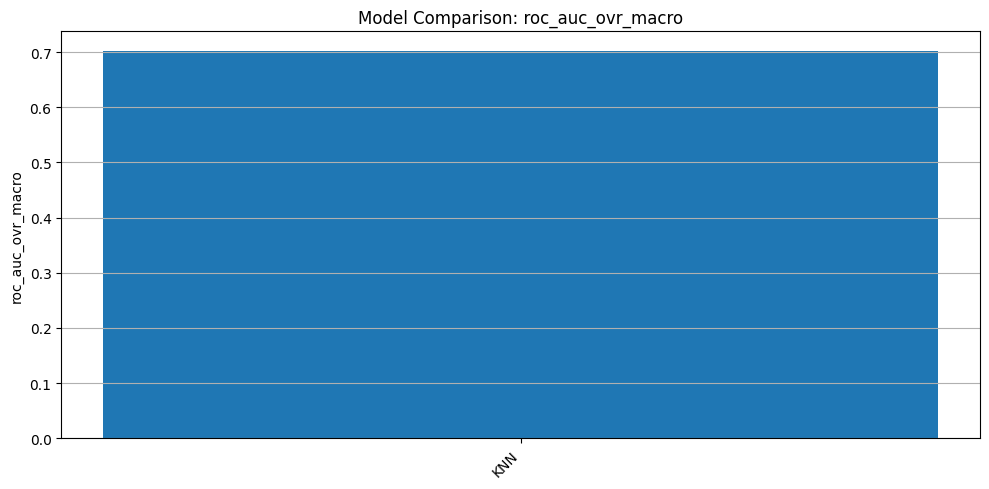


Best model based on average Macro F1: KNN


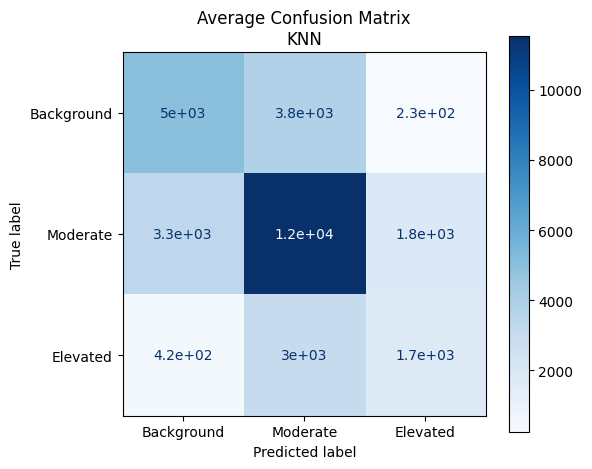


Fitting final interpretation model on all data...


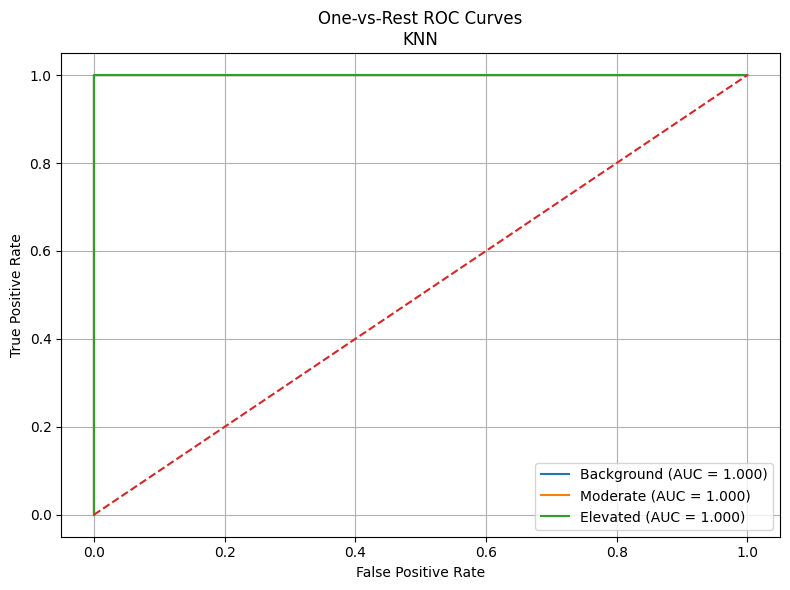

In [ ]:
# ============================================================
# 12. PHYSICS BASELINE EVALUATION
# ============================================================
print("\n" + "=" * 100)
print("PHYSICS-BASED BASELINE: NAIRASV3")
print("=" * 100)

for train_name, valid_name, test_name in rotations:

    test_df = datasets[test_name].copy()
    y_test = test_df[TARGET].copy()

    y_test, valid_target_mask = clean_target(y_test)
    test_df = test_df.loc[valid_target_mask]

    y_pred_phys = physics_baseline_predict(test_df, nairas_col="NAIRASV3")
    valid_pred_mask = pd.Series(y_pred_phys).isin(CLASS_LABELS)

    y_test_clean = y_test.loc[valid_pred_mask]
    y_pred_phys_clean = y_pred_phys.loc[valid_pred_mask].astype(int)

    if len(y_test_clean) == 0:
        continue

    metrics = evaluate_multiclass(y_test_clean, y_pred_phys_clean, y_proba=None)

    result_row = {
        "model": "Physics Baseline (NAIRASV3)",
        "train_set": train_name,
        "valid_set": valid_name,
        "test_set": test_name,
        **metrics
    }
    all_results.append(result_row)

    cm = confusion_matrix(y_test_clean, y_pred_phys_clean, labels=CLASS_LABELS)
    all_conf_matrices.append({
        "model": "Physics Baseline (NAIRASV3)",
        "rotation": f"{train_name}-{valid_name}-{test_name}",
        "cm": cm
    })

    print(f"\nRotation: Train={train_name}, Validation={valid_name}, Test={test_name}")
    print(f"Accuracy        : {metrics['accuracy']:.4f}")
    print(f"Precision Macro : {metrics['precision_macro']:.4f}")
    print(f"Recall Macro    : {metrics['recall_macro']:.4f}")
    print(f"F1 Macro        : {metrics['f1_macro']:.4f}")

# ============================================================
# 13. RESULTS TABLE
# ============================================================
results_df = pd.DataFrame(all_results)

print("\n" + "=" * 100)
print("ALL RESULTS")
print("=" * 100)
print(results_df)

# save
results_df.to_csv("all_model_rotation_results.csv", index=False)
print("\nSaved: all_model_rotation_results.csv")

# ============================================================
# 14. FAILED RUNS TABLE
# ============================================================
failed_df = pd.DataFrame(failed_runs)

if len(failed_df) > 0:
    print("\n" + "=" * 100)
    print("FAILED RUNS")
    print("=" * 100)
    print(failed_df)
    failed_df.to_csv("failed_runs_debug.csv", index=False)
    print("\nSaved: failed_runs_debug.csv")

# ============================================================
# 15. SUMMARY TABLE
# ============================================================
summary_df = (
    results_df.groupby("model")[["accuracy", "precision_macro", "recall_macro", "f1_macro", "roc_auc_ovr_macro"]]
    .agg(["mean", "std"])
    .round(4)
)

print("\n" + "=" * 100)
print("SUMMARY BY MODEL")
print("=" * 100)
print(summary_df)

summary_df.to_csv("summary_by_model.csv")
print("\nSaved: summary_by_model.csv")

plot_df = (
    results_df.groupby("model")[["accuracy", "precision_macro", "recall_macro", "f1_macro", "roc_auc_ovr_macro"]]
    .mean()
    .reset_index()
)

# ============================================================
# 16. MODEL COMPARISON PLOTS
# ============================================================
metrics_to_plot = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "roc_auc_ovr_macro"]

for metric in metrics_to_plot:
    plt.figure(figsize=(10, 5))
    plt.bar(plot_df["model"], plot_df[metric])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(metric)
    plt.title(f"Model Comparison: {metric}")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()

# ============================================================
# 17. BEST MODEL BASED ON AVERAGE MACRO F1
# ============================================================
best_model_name = (
    plot_df.sort_values("f1_macro", ascending=False)
    .iloc[0]["model"]
)

print("\nBest model based on average Macro F1:", best_model_name)

# ============================================================
# 18. AVERAGE CONFUSION MATRIX FOR BEST MODEL
# ============================================================
best_cms = [item["cm"] for item in all_conf_matrices if item["model"] == best_model_name]

if len(best_cms) > 0:
    avg_cm = np.mean(best_cms, axis=0)

    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=avg_cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap="Blues", colorbar=True)
    ax.set_title(f"Average Confusion Matrix\n{best_model_name}")
    plt.tight_layout()
    plt.show()

# ============================================================
# 19. FIT BEST NON-PHYSICS MODEL ON ALL DATA FOR INTERPRETATION
# ============================================================
if best_model_name != "Physics Baseline (NAIRASV3)":

    full_df = pd.concat([datasets["armas1"], datasets["armas2"], datasets["armas3"]], axis=0)

    X_full, y_full = split_xy(full_df)
    X_full = clean_features(X_full)
    y_full, full_mask = clean_target(y_full)
    X_full = X_full.loc[full_mask]

    final_estimator = models[best_model_name]

    final_model = Pipeline([
        ("prep", preprocessor),
        ("clf", final_estimator)
    ])

    print("\nFitting final interpretation model on all data...")
    final_model.fit(X_full, y_full)

# ============================================================
# 20. ROC CURVES FOR FINAL BEST MODEL
# ============================================================
if best_model_name != "Physics Baseline (NAIRASV3)":

    demo_df = datasets["armas3"].copy()
    X_demo, y_demo = split_xy(demo_df)
    X_demo = clean_features(X_demo)
    y_demo, mask_demo = clean_target(y_demo)
    X_demo = X_demo.loc[mask_demo]

    if hasattr(final_model.named_steps["clf"], "predict_proba"):
        try:
            y_score = final_model.predict_proba(X_demo)
            y_demo_bin = label_binarize(y_demo, classes=CLASS_LABELS)

            plt.figure(figsize=(8, 6))

            for i, class_name in enumerate(CLASS_NAMES):
                fpr, tpr, _ = roc_curve(y_demo_bin[:, i], y_score[:, i])
                roc_auc = auc(fpr, tpr)
                plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.3f})")

            plt.plot([0, 1], [0, 1], linestyle="--")
            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.title(f"One-vs-Rest ROC Curves\n{best_model_name}")
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print("ROC plotting skipped:", e)

# ============================================================
# 21. PERMUTATION IMPORTANCE
# ============================================================
if best_model_name != "Physics Baseline (NAIRASV3)":

    demo_df = datasets["armas3"].copy()
    X_demo, y_demo = split_xy(demo_df)
    X_demo = clean_features(X_demo)
    y_demo, mask_demo = clean_target(y_demo)
    X_demo = X_demo.loc[mask_demo]

    try:
        perm = permutation_importance(
            final_model,
            X_demo,
            y_demo,
            n_repeats=10,
            random_state=42,
            scoring="f1_macro"
        )

        importance_df = pd.DataFrame({
            "feature": X_demo.columns,
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std
        }).sort_values("importance_mean", ascending=False)

        print("\nTop 15 permutation importance features:")
        print(importance_df.head(15))

        importance_df.to_csv("permutation_importance_best_model.csv", index=False)
        print("\nSaved: permutation_importance_best_model.csv")

        plt.figure(figsize=(10, 6))
        top_perm = importance_df.head(15).sort_values("importance_mean")
        plt.barh(top_perm["feature"], top_perm["importance_mean"])
        plt.xlabel("Permutation Importance")
        plt.title(f"Permutation Importance\n{best_model_name}")
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print("Permutation importance failed:", e)

# ============================================================
# 22. SHAP BEESWARM PLOT
# ============================================================
if best_model_name != "Physics Baseline (NAIRASV3)" and SHAP_AVAILABLE:

    demo_df = datasets["armas3"].copy()
    X_demo, y_demo = split_xy(demo_df)
    X_demo = clean_features(X_demo)
    y_demo, mask_demo = clean_target(y_demo)
    X_demo = X_demo.loc[mask_demo]

    try:
        X_transformed = final_model.named_steps["prep"].transform(X_demo)
        feature_names = final_model.named_steps["prep"].get_feature_names_out()

        if hasattr(X_transformed, "toarray"):
            X_transformed = X_transformed.toarray()

        X_transformed_df = pd.DataFrame(X_transformed, columns=feature_names)

        clf = final_model.named_steps["clf"]

        sample_size = min(500, len(X_transformed_df))
        X_shap = X_transformed_df.sample(sample_size, random_state=42)

        # Tree models and some other models may work with generic explainer
        explainer = shap.Explainer(clf, X_shap)
        shap_values = explainer(X_shap)

        if len(shap_values.values.shape) == 3:
            for class_idx, class_name in enumerate(CLASS_NAMES):
                class_explanation = shap.Explanation(
                    values=shap_values.values[:, :, class_idx],
                    base_values=shap_values.base_values[:, class_idx]
                    if np.array(shap_values.base_values).ndim > 1 else shap_values.base_values,
                    data=X_shap.values,
                    feature_names=X_shap.columns
                )

                plt.figure(figsize=(10, 6))
                shap.plots.beeswarm(class_explanation, max_display=15, show=False)
                plt.title(f"SHAP Beeswarm - {class_name}\n{best_model_name}")
                plt.tight_layout()
                plt.show()
        else:
            plt.figure(figsize=(10, 6))
            shap.plots.beeswarm(shap_values, max_display=15, show=False)
            plt.title(f"SHAP Beeswarm\n{best_model_name}")
            plt.tight_layout()
            plt.show()

    except Exception as e:
        print("SHAP beeswarm failed:", e)

# ============================================================
# 23. CLASSIFICATION REPORT FOR FINAL BEST MODEL
# ============================================================
if best_model_name != "Physics Baseline (NAIRASV3)":
    try:
        demo_df = datasets["armas3"].copy()
        X_demo, y_demo = split_xy(demo_df)
        X_demo = clean_features(X_demo)
        y_demo, mask_demo = clean_target(y_demo)
        X_demo = X_demo.loc[mask_demo]

        y_demo_pred = final_model.predict(X_demo)

        print("\nDetailed Classification Report")
        print(classification_report(y_demo, y_demo_pred, target_names=CLASS_NAMES))
    except Exception as e:
        print("Classification report failed:", e)

# ============================================================
# 24. SUGGESTED FINAL SCIENTIFIC FIGURES
# ============================================================
print("\nRecommended final figures for report:")
print("1. Model comparison bar plot for Macro F1")
print("2. Model comparison bar plot for ROC-AUC")
print("3. Average confusion matrix for best model")
print("4. Physics baseline vs best ML model comparison")
print("5. Permutation importance plot")
if SHAP_AVAILABLE:
    print("6. SHAP beeswarm plot, especially Elevated class")
else:
    print("6. SHAP beeswarm skipped because shap is not installed")